# CUDA GEMV
theres no of different kernels in place, we have attentions kernels specifically used for QKV blocks but it all starts with basic one GEMV (GEneral Matrix-Vector multiplication)
In simple terms,  matrix * vector 
```text
A = matrix of shape [M, K]
x = vector of shape [K]
y = vector of shape [M]

y = A * x
```



what is GEMV (General Matrix-Vector Multiplication) is memory problem, like how much meory you will move between on vs off-chip for the matrix operations 

in this article we see how much can we write custom kernels and optimize then native Nvidia cublas , cuda and Pytorch


keep in mind that we perform Wx + b

## 1. Intro




before we move into the matrix operations we see how does the GPU chips looks like and see where data goes and stuff 

The goal is very simple: your GPU has fast compute but it doesnt know the best way to cache, reuse, and move data for your exact workload. 

so with kernels, you guide how the data should move and be reused efficiently.
 
How does the data move inside chips?
* ON-chip is where most of the computation happens.
* OFF-chip memory stores the large data needed for computation.

each time we perform matrix multiplication, values are accessed from HBM and moved closer to the compute units

We have different cache/memory layers on-chip:
1. L2 cache layer across SMs
2.  L1 cache layer per SM
3.  Shared memory per thread block
4.  Registers per thread

each layer is used for a different purpose at the thread, block, warp, and SM level.

simple terms:
you read data once from HBM, keep it closer to the compute units, cache/reuse it at each layer level, and avoid getting it again and again from HBM because the latency and memory traffic can kill throughput.

<!-- ![as](/data/inference-book/designs/h100-blackwell.png)  -->
<img src="/data/inference-book/designs/h100-blackwell.png" width="800" height="600" alt="H100 Blackwell design">

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from torch.utils.cpp_extension import load, load_inline

assert torch.cuda.is_available(), (
    "CUDA GPU is required. Select a CUDA-enabled Python environment and verify "
    "that the NVIDIA driver is visible before running this notebook."
)

DEVICE_INDEX = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{DEVICE_INDEX}")
GPU = torch.cuda.get_device_properties(DEVICE_INDEX)

# Keep the FP32 benchmark as FP32 math instead of silently using TF32 tensor cores.
torch.backends.cuda.matmul.allow_tf32 = False
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("highest")

torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
pd.set_option("display.precision", 4)

print(f"GPU name:           {GPU.name}")
print(f"CUDA version:       {torch.version.cuda}")
print(f"PyTorch version:    {torch.__version__}")
print(f"Compute capability: {GPU.major}.{GPU.minor}")
print(f"Total GPU memory:   {GPU.total_memory / 2**30:.2f} GiB")
print(f"TF32 matmul:        {torch.backends.cuda.matmul.allow_tf32}")


GPU name:           NVIDIA GeForce RTX 4050 Laptop GPU
CUDA version:       13.0
PyTorch version:    2.12.1+cu130
Compute capability: 8.9
Total GPU memory:   5.64 GiB
TF32 matmul:        False


In [17]:
cpp_source = r"""
#include <torch/extension.h>
#include <cuda_runtime_api.h>
#include <sstream>
#include <string>

std::string get_cuda_device_info(int device_id) {
    cudaDeviceProp prop;
    cudaError_t err = cudaGetDeviceProperties(&prop, device_id);

    if (err != cudaSuccess) {
        return std::string("error=") + cudaGetErrorString(err);
    }

    std::ostringstream out;

    out << "name=" << prop.name << "\n";
    out << "major=" << prop.major << "\n";
    out << "minor=" << prop.minor << "\n";

    out << "multiProcessorCount=" << prop.multiProcessorCount << "\n";
    out << "warpSize=" << prop.warpSize << "\n";
    out << "maxThreadsPerMultiProcessor=" << prop.maxThreadsPerMultiProcessor << "\n";
    out << "maxThreadsPerBlock=" << prop.maxThreadsPerBlock << "\n";

    out << "sharedMemPerBlock=" << prop.sharedMemPerBlock << "\n";
    out << "sharedMemPerMultiprocessor=" << prop.sharedMemPerMultiprocessor << "\n";

    out << "regsPerBlock=" << prop.regsPerBlock << "\n";
    out << "regsPerMultiprocessor=" << prop.regsPerMultiprocessor << "\n";

    out << "l2CacheSize=" << prop.l2CacheSize << "\n";
    out << "totalGlobalMem=" << prop.totalGlobalMem << "\n";

    out << "memoryClockRate=" << prop.memoryClockRate << "\n";
    out << "memoryBusWidth=" << prop.memoryBusWidth << "\n";
    out << "clockRate=" << prop.clockRate << "\n";

    return out.str();
}

PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) {
    m.def("get_cuda_device_info", &get_cuda_device_info);
}
"""

cuda_device_info = load_inline(
    name="cuda_device_info_ext_v2",
    cpp_sources=cpp_source,
    with_cuda=True,
    verbose=False,
)

raw = cuda_device_info.get_cuda_device_info(torch.cuda.current_device())

info = {}
for line in raw.strip().splitlines():
    key, value = line.split("=", 1)
    info[key] = value

if "error" in info:
    raise RuntimeError(info["error"])

def as_int(key):
    return int(info[key])

# Basic architecture
gpu_name = info["name"]
compute_capability = f"{info['major']}.{info['minor']}"

sm_count = as_int("multiProcessorCount")
warp_size = as_int("warpSize")
max_threads_per_sm = as_int("maxThreadsPerMultiProcessor")
max_threads_per_block = as_int("maxThreadsPerBlock")

max_warps_per_sm = max_threads_per_sm // warp_size
total_max_warps = sm_count * max_warps_per_sm

# On-chip resources
shared_memory_per_block = as_int("sharedMemPerBlock")
shared_memory_per_sm = as_int("sharedMemPerMultiprocessor")

regs_per_block = as_int("regsPerBlock")
regs_per_sm = as_int("regsPerMultiprocessor")

l2_cache_size = as_int("l2CacheSize")

# Off-chip memory
total_global_mem = as_int("totalGlobalMem")
memory_clock_khz = as_int("memoryClockRate")
memory_bus_width_bits = as_int("memoryBusWidth")

# Core clock
core_clock_khz = as_int("clockRate")

# Peak bandwidth calculation
#
# CUDA reports memoryClockRate in kHz.
# For GDDR memory:
# effective transfer rate = 2 × memory clock
#
# Peak bandwidth:
# GB/s = 2 × memory_clock_khz × 1000 × memory_bus_width_bits / 8 / 1e9
peak_bandwidth_GBs = (
    2 * memory_clock_khz * 1000 * memory_bus_width_bits / 8 / 1e9
)
peak_bandwidth_GiBs = peak_bandwidth_GBs / 1.073741824

rows = [
    ("GPU name", gpu_name, "Device name"),
    ("Compute capability", compute_capability, "CUDA architecture version"),

    ("SM count", sm_count, "Number of Streaming Multiprocessors"),
    ("Warp size", warp_size, "Threads per warp"),
    ("Max threads / SM", max_threads_per_sm, "Maximum resident CUDA threads per SM"),
    ("Max resident warps / SM", max_warps_per_sm, "max_threads_per_sm / warp_size"),
    ("Total max resident warps", total_max_warps, "SM count × max resident warps per SM"),
    ("Max threads / block", max_threads_per_block, "Maximum CUDA threads per block"),

    ("Shared memory / block", f"{shared_memory_per_block / 1024:.1f} KiB", "On-chip shared memory limit per block"),
    ("Shared memory / SM", f"{shared_memory_per_sm / 1024:.1f} KiB", "On-chip shared memory available per SM"),

    ("Registers / block", regs_per_block, "On-chip register limit per block"),
    ("Registers / SM", regs_per_sm, "On-chip register file per SM"),

    ("L2 cache", f"{l2_cache_size / 1024**2:.2f} MiB", "On-chip / near-chip cache"),
    ("Global memory / VRAM", f"{total_global_mem / 1024**3:.2f} GiB", "Off-chip GPU memory"),

    ("Core clock", f"{core_clock_khz / 1000:.1f} MHz", "Reported GPU core clock"),
    ("Memory clock", f"{memory_clock_khz / 1000:.1f} MHz", "Reported CUDA memory clock"),
    ("Memory bus width", f"{memory_bus_width_bits} bit", "Off-chip memory bus width"),

    ("Peak memory bandwidth", f"{peak_bandwidth_GBs:.2f} GB/s", "Decimal bandwidth"),
    ("Peak memory bandwidth", f"{peak_bandwidth_GiBs:.2f} GiB/s", "Binary bandwidth"),
]

arch_df = pd.DataFrame(rows, columns=["Metric", "Value", "Meaning"])
display(arch_df)

,Metric,Value,Meaning
0,GPU name,NVIDIA GeForce RTX 4050 Laptop GPU,Device name
1,Compute capability,8.9,CUDA architecture version
2,SM count,20,Number of Streaming Multiprocessors
3,Warp size,32,Threads per warp
4,Max threads / SM,1536,Maximum resident CUDA threads per SM
5,Max resident warps / SM,48,max_threads_per_sm / warp_size
6,Total max resident warps,960,SM count × max resident warps per SM
7,Max threads / block,1024,Maximum CUDA threads per block
8,Shared memory / block,48.0 KiB,On-chip shared memory limit per block
9,Shared memory / SM,100.0 KiB,On-chip shared memory available per SM


## 2. GEMV problem definition

GEMV is mostly a memory movement problem, not a math problem.

we read the W from the HBM

In [18]:
M = 20096
N = 20096
PEAK_BANDWIDTH_GBPS = peak_bandwidth_GBs  # Change this for your GPU before interpreting peak %.

BENCHMARK_CASES = [
    {
        "precision": "FP16",
        "dtype": torch.float16,
        "rtol": 1e-2,
        "atol": 1e-1,
    },
    {
        "precision": "FP32",
        "dtype": torch.float32,
        "rtol": 1e-4,
        "atol": 1e-3,
    },
]

PROBLEMS = {}
for case in BENCHMARK_CASES:
    precision = case["precision"]
    dtype = case["dtype"]
    W = torch.randn((M, N), device=DEVICE, dtype=dtype).contiguous()
    x = torch.randn((N,), device=DEVICE, dtype=dtype).contiguous()

    assert W.shape == (M, N) and x.shape == (N,)
    assert W.is_contiguous() and x.is_contiguous()

    weight_bytes = M * N * W.element_size()
    x_bytes = N * x.element_size()
    y_bytes = M * torch.empty((), dtype=dtype).element_size()
    logical_memory_bytes = weight_bytes + x_bytes + y_bytes

    PROBLEMS[precision] = {
        **case,
        "W": W,
        "x": x,
        "weight_bytes": weight_bytes,
        "x_bytes": x_bytes,
        "y_bytes": y_bytes,
        "logical_memory_bytes": logical_memory_bytes,
    }

    print(f"{precision}")
    print(f"  W: {tuple(W.shape)}, {W.dtype}, {weight_bytes / 1e6:.3f} MB")
    print(f"  x: {tuple(x.shape)}, {x.dtype}, {x_bytes / 1e3:.3f} KB")
    print(f"  y: ({M},), {dtype}, {y_bytes / 1e3:.3f} KB")
    print(f"  Logical traffic per GEMV: {logical_memory_bytes / 1e6:.3f} MB")


FP16
  W: (20096, 20096), torch.float16, 807.698 MB
  x: (20096,), torch.float16, 40.192 KB
  y: (20096,), torch.float16, 40.192 KB
  Logical traffic per GEMV: 807.779 MB
FP32
  W: (20096, 20096), torch.float32, 1615.397 MB
  x: (20096,), torch.float32, 80.384 KB
  y: (20096,), torch.float32, 80.384 KB
  Logical traffic per GEMV: 1615.558 MB


## smaller value peak


since my weights 1096,1096 is comes around < 24MB
the whole matrix fits under the l2 cache so it never have the chance to go read HBM

where my bandwidth explodes to 
* FP32 Optimized CUDA v3 = 519 GB/s
* percent_peak_bandwidth = 270%

which is not what we wanted here right ? so lets try with something 
that exceeds 24MB 

## 3. Inline CUDA extension through torch

In [19]:
GPU.major , GPU.minor 

(8, 9)

In [20]:
from pathlib import Path

def resolve_source_file(filename):
    candidates = (
        Path.cwd() / filename,
        Path.cwd() / "kernels" / filename,
    )
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    searched = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")

def cublas_link_flags():
    # Prefer the cuBLAS major bundled with PyTorch. This matters when the
    # system CUDA toolkit and the PyTorch CUDA build have different majors.
    cuda_major = torch.version.cuda.split(".", 1)[0]
    site_packages = Path(torch.__file__).resolve().parent.parent
    candidates = (
        site_packages / "nvidia" / f"cu{cuda_major}" / "lib"
        / f"libcublas.so.{cuda_major}",
        site_packages / "nvidia" / "cublas" / "lib"
        / f"libcublas.so.{cuda_major}",
    )
    for library in candidates:
        if library.is_file():
            return [str(library), f"-Wl,-rpath,{library.parent}"]
    return ["-lcublas"]

CPP_SOURCE_PATH = resolve_source_file("gemv_bindings.cpp")
CUDA_SOURCE_PATH = resolve_source_file("gemv_kernels.cu")
cpp_source = CPP_SOURCE_PATH.read_text(encoding="utf-8")
cuda_source = CUDA_SOURCE_PATH.read_text(encoding="utf-8")
CUBLAS_LINK_FLAGS = cublas_link_flags()

print(f"C++ bindings: {CPP_SOURCE_PATH}")
print(f"CUDA kernels: {CUDA_SOURCE_PATH}")
print(f"cuBLAS link flags: {CUBLAS_LINK_FLAGS}")

C++ bindings: /data/inference-book/kernels/GEMV/gemv_bindings.cpp
CUDA kernels: /data/inference-book/kernels/GEMV/gemv_kernels.cu
cuBLAS link flags: ['/data/inference-book/.venv/lib/python3.12/site-packages/nvidia/cu13/lib/libcublas.so.13', '-Wl,-rpath,/data/inference-book/.venv/lib/python3.12/site-packages/nvidia/cu13/lib']


In [21]:
# Compile the external native sources through PyTorch's inline extension cache.
extension_name = f"gemv_cuda_ext_v3_same_dtype_sm{GPU.major}{GPU.minor}"
gemv_ext = load_inline(
    name=extension_name,
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=None,
    extra_cflags=["-O3"],
    extra_cuda_cflags=["-O3", "-lineinfo"],
    extra_ldflags=CUBLAS_LINK_FLAGS,
    with_cuda=True,
    verbose=True,
)

print(f"Loaded inline extension: {extension_name}")

Loaded inline extension: gemv_cuda_ext_v3_same_dtype_sm89


## 4. PyTorch baseline 

In [22]:
RUNNERS = {precision: {} for precision in PROBLEMS}

for precision, problem in PROBLEMS.items():
    W = problem["W"]
    x = problem["x"]
    y_torch = torch.empty((M,), device=DEVICE, dtype=problem["dtype"])

    def run_pytorch(W=W, x=x, y_torch=y_torch):
        torch.matmul(W, x, out=y_torch)
        return y_torch

    RUNNERS[precision]["PyTorch torch.matmul"] = run_pytorch
    result = run_pytorch()
    torch.cuda.synchronize()
    print(f"{precision} PyTorch result dtype: {result.dtype}")


FP16 PyTorch result dtype: torch.float16
FP32 PyTorch result dtype: torch.float32


## 5. Naive approach

In [23]:
for precision, problem in PROBLEMS.items():
    W = problem["W"]
    x = problem["x"]
    y_naive = torch.empty((M,), device=DEVICE, dtype=problem["dtype"])

    def run_naive_cuda(W=W, x=x, y_naive=y_naive):
        gemv_ext.naive_gemv_out(W, x, y_naive)
        return y_naive

    RUNNERS[precision]["Naive CUDA"] = run_naive_cuda
    run_naive_cuda()
    torch.cuda.synchronize()
    print(f"{precision} Naive CUDA result dtype: {y_naive.dtype}")


FP16 Naive CUDA result dtype: torch.float16
FP32 Naive CUDA result dtype: torch.float32


## 6. Optimized CUDA GEMV

We compare four custom optimized variants:

- `Optimized CUDA`: one 256-thread block computes one output row.

> 256 threads per row
> High per-row memory parallelism
> More blocks, cross-warp reduction

- `Optimized CUDA v1`: one warp computes one output row, so there is no shared-memory row reduction.

> 1 warp per row, 8 rows/block
> Less block overhead, no shared row reduction
> Less per-row parallelism


- `Optimized CUDA v2`: one warp computes one row and the block stages vector tiles in shared memory.

> v1 + shared-memory x tiling
> Reuses x across rows
> x is tiny; adds sync/tile overhead


- `Optimized CUDA v3`: for FP16, the block stages the full vector in shared memory when it fits; FP32 falls back to v1

> v1 + full x in shared memory
> Reuses full x with one sync
> FP16-only path; still limited by W
> faster fp16 and fallback to v1 for fp32

All variants use same-dtype inputs/outputs for each benchmark case and accumulate partial sums in FP32.


In [24]:
OPTIMIZED_VARIANTS = [
    ("Optimized CUDA", gemv_ext.optimized_gemv_out),
    ("Optimized CUDA v1", gemv_ext.optimized_gemv_v1_out),
    ("Optimized CUDA v2", gemv_ext.optimized_gemv_v2_out),
    ("Optimized CUDA v3", gemv_ext.optimized_gemv_v3_out),
]

for precision, problem in PROBLEMS.items():
    W = problem["W"]
    x = problem["x"]

    for method_name, kernel in OPTIMIZED_VARIANTS:
        y_optimized = torch.empty((M,), device=DEVICE, dtype=problem["dtype"])

        def run_optimized_cuda(W=W, x=x, y_optimized=y_optimized, kernel=kernel):
            kernel(W, x, y_optimized)
            return y_optimized

        RUNNERS[precision][method_name] = run_optimized_cuda
        run_optimized_cuda()
        torch.cuda.synchronize()
        print(f"{precision} {method_name} result dtype: {y_optimized.dtype}")


FP16 Optimized CUDA result dtype: torch.float16
FP16 Optimized CUDA v1 result dtype: torch.float16
FP16 Optimized CUDA v2 result dtype: torch.float16
FP16 Optimized CUDA v3 result dtype: torch.float16
FP32 Optimized CUDA result dtype: torch.float32
FP32 Optimized CUDA v1 result dtype: torch.float32
FP32 Optimized CUDA v2 result dtype: torch.float32
FP32 Optimized CUDA v3 result dtype: torch.float32


## 7. Direct cuBLAS GEMV

This path calls `cublasGemmEx` directly from the CUDA extension. We express GEMV as a one-column GEMM:

[M, N] @ [N, 1] -> [M, 1]

This gives us a direct vendor-library baseline without going through `torch.matmul`.

In [25]:
for precision, problem in PROBLEMS.items():
    W = problem["W"]
    x = problem["x"]
    y_cublas = torch.empty((M,), device=DEVICE, dtype=problem["dtype"])

    def run_cublas_direct(W=W, x=x, y_cublas=y_cublas):
        gemv_ext.cublas_gemv_out(W, x, y_cublas)
        return y_cublas

    RUNNERS[precision]["cuBLAS direct"] = run_cublas_direct
    run_cublas_direct()
    torch.cuda.synchronize()
    print(f"{precision} Direct cuBLAS result dtype: {y_cublas.dtype}")


FP16 Direct cuBLAS result dtype: torch.float16
FP32 Direct cuBLAS result dtype: torch.float32


## Benchmark

our peak_memory_bandwith is around 192 GB/seconds for the RTX 4050 
ada lovelace architecture design 

so we have:
1. CUDA Cores: 2,560 unified shaders.
2. Tensor Cores: 80  



In [27]:
def benchmark_cuda(fn, warmup=25, repeat=100):
    for _ in range(warmup):
        fn()

    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(repeat):
        fn()
    end.record()

    torch.cuda.synchronize()

    total_ms = start.elapsed_time(end)
    return (total_ms * 1000.0) / repeat  # microseconds


def error_metrics(actual, expected):
    actual_f = actual.float()
    expected_f = expected.float()

    abs_error = (actual_f - expected_f).abs()
    rel_error = abs_error / expected_f.abs().clamp_min(1e-6)

    return {
        "max_abs_error": abs_error.max().item(),
        "mean_abs_error": abs_error.mean().item(),
        "max_rel_error": rel_error.max().item(),
    }


timings = {}
correctness = {}

for precision, problem in PROBLEMS.items():
    W = problem["W"]
    x = problem["x"]
    dtype = problem["dtype"]

    # FP32 reference for stable math, then cast back to tested dtype
    reference = torch.matmul(W.float(), x.float()).to(dtype=dtype)
    torch.cuda.synchronize()

    timings[precision] = {}

    for method, runner in RUNNERS[precision].items():
        torch.cuda.empty_cache()

        # Correctness
        output = runner()
        torch.cuda.synchronize()

        correctness[(precision, method)] = error_metrics(output, reference)

        torch.testing.assert_close(
            output,
            reference,
            rtol=problem["rtol"],
            atol=problem["atol"],
        )

        # Timing
        latency_us = benchmark_cuda(runner)

        timings[precision][method] = {
            "latency_us": latency_us,
        }

## 10. Metric calculations

In [28]:
def bandwidth_gbps(bytes_moved, latency_us):
    return bytes_moved / (latency_us * 1e-6) / 1e9

rows = []

for precision, problem in PROBLEMS.items():
    naive_latency_us = timings[precision]["Naive CUDA"]["latency_us"]
    logical_memory_bytes = problem["logical_memory_bytes"]

    for method in RUNNERS[precision]:
        latency_us = timings[precision][method]["latency_us"]
        effective_bandwidth = bandwidth_gbps(logical_memory_bytes, latency_us)
        rows.append(
            {
                "precision": precision,
                "method": method,
                "latency_us": latency_us,
                "bandwidth_GBps": effective_bandwidth,
                "percent_peak_bandwidth": effective_bandwidth / PEAK_BANDWIDTH_GBPS * 100.0,
                "speedup_vs_naive": naive_latency_us / latency_us,
                **correctness[(precision, method)],
            }
        )

results = pd.DataFrame(rows)
results


,precision,method,latency_us,bandwidth_GBps,percent_peak_bandwidth,speedup_vs_naive,max_abs_error,mean_abs_error,max_rel_error
0,FP16,PyTorch torch.matmul,4305.5002,187.6156,97.7042,3.4887,0.1250,5.3469e-05,0.0168
1,FP16,Naive CUDA,15020.6873,53.7778,28.0057,1.0000,0.2500,2.6884e-04,0.0367
2,FP16,Optimized CUDA,4488.3865,179.9709,93.7231,3.3466,0.0625,8.2070e-06,0.0137
3,FP16,Optimized CUDA v1,4934.1849,163.7107,85.2553,3.0442,0.1250,4.9485e-05,0.0168
4,FP16,Optimized CUDA v2,4843.6099,166.7721,86.8496,3.1011,0.1250,3.0446e-05,0.0137
5,FP16,Optimized CUDA v3,4333.5681,186.4004,97.0714,3.4661,0.1250,4.9485e-05,0.0168
6,FP16,cuBLAS direct,5209.6820,155.0534,80.7469,2.8832,0.1250,5.3469e-05,0.0168
7,FP32,PyTorch torch.matmul,8957.4799,180.3585,93.9250,2.9840,0.0000,0.0000e+00,0.0000
8,FP32,Naive CUDA,26729.5020,60.4410,31.4757,1.0000,0.0027,2.5659e-04,0.0041
9,FP32,Optimized CUDA,8604.5801,187.7555,97.7771,3.1064,0.0001,2.7026e-05,0.0017


## 12. Plots

Four figures compare FP16 and FP32 side-by-side for each method: latency, logical effective bandwidth, configured-peak utilization, and speedup over the naive kernel.

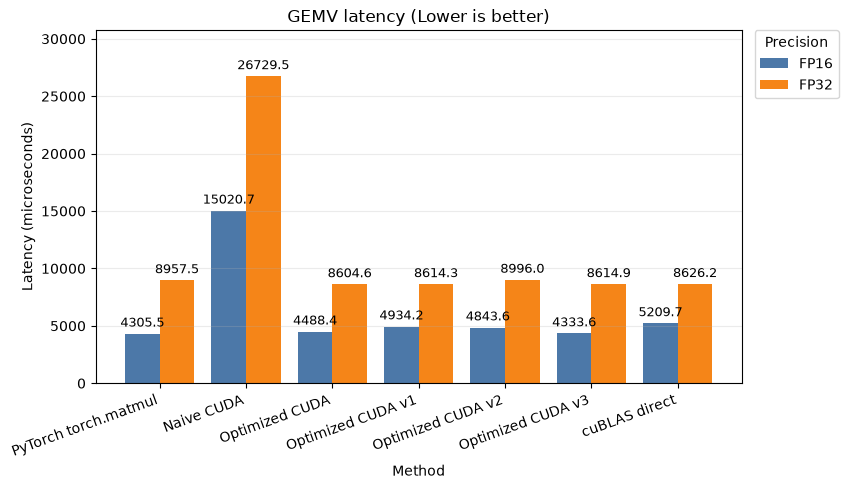

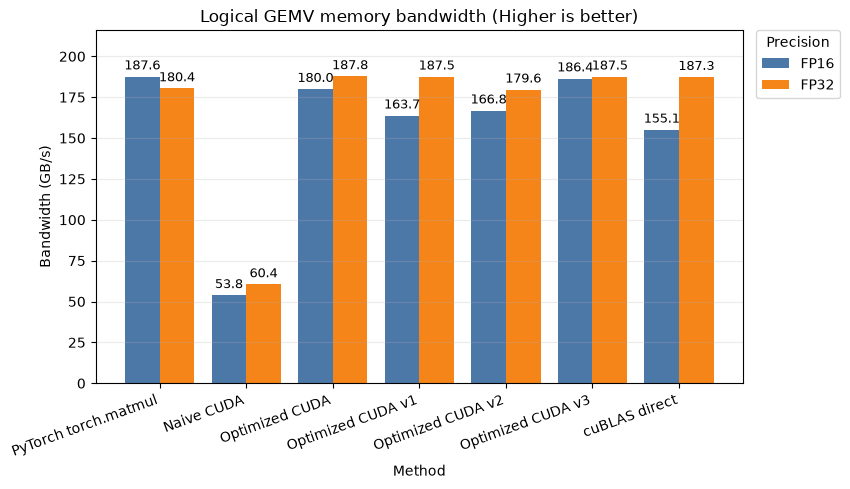

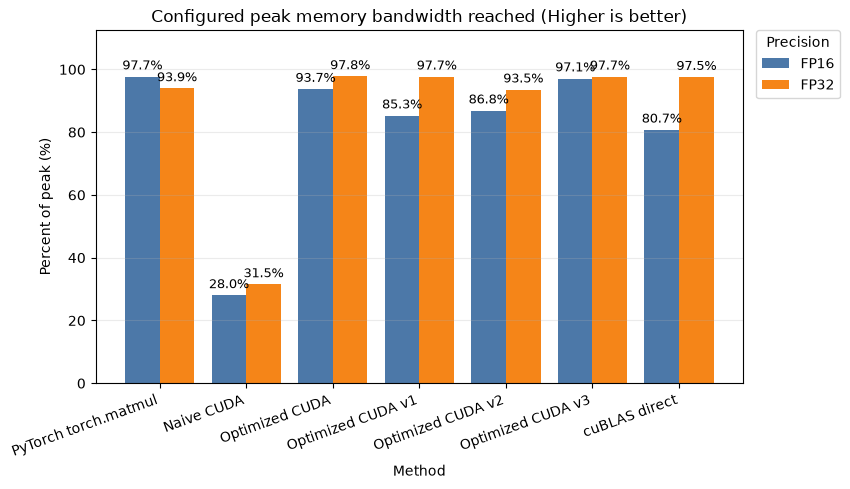

In [ ]:
PLOT_SPECS = [
    ("latency_us", "GEMV latency", "Latency (microseconds)", "{:.1f}", "Lower is better"),
    ("bandwidth_GBps", "Logical GEMV memory bandwidth", "Bandwidth (GB/s)", "{:.1f}", "Higher is better"),
    (
        "percent_peak_bandwidth",
        "Configured peak memory bandwidth reached",
        "Percent of peak (%)",
        "{:.1f}%",
        "Higher is better",
    ),
    # ("speedup_vs_naive", "GEMV speedup vs naive CUDA", "Speedup (x)", "{:.2f}x", "Higher is better"),
]

PRECISION_COLORS = {
    "FP16": "#4C78A8",
    "FP32": "#F58518",
}

methods = results["method"].drop_duplicates().tolist()
precisions = results["precision"].drop_duplicates().tolist()

x = np.arange(len(methods))
bar_width = 0.8 / len(precisions)

for column, title, ylabel, value_format, direction_note in PLOT_SPECS:
    fig, ax = plt.subplots(figsize=(10, 5))

    for i, precision in enumerate(precisions):
        precision_results = (
            results[results["precision"] == precision]
            .set_index("method")
            .reindex(methods)
        )

        values = precision_results[column].to_numpy()
        offset = (i - (len(precisions) - 1) / 2) * bar_width

        bars = ax.bar(
            x + offset,
            values,
            width=bar_width,
            label=precision,
            color=PRECISION_COLORS.get(precision),
        )

        ax.bar_label(
            bars,
            labels=[value_format.format(value) for value in values],
            padding=3,
            fontsize=9,
        )

    ax.set_title(f"{title} ({direction_note})")
    ax.set_xlabel("Method")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ymax = np.nanmax(results[column].to_numpy())
    ax.set_ylim(0, ymax * 1.15)
    ax.legend(
    title="Precision",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
    )

    fig.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show() 

achieved 90% peak memory bandwith on the optimzed kernels some version beat the cublas baseline 
utilizin this peak memory bandwith means we are utilizing the GPU to the fullest 

which is what we wanted here 


## Key improvements

### Why v3 beats first Optimized CUDA in FP16

we can also clearly see that optimized v1 FP32 has same as the v3 but
Fp16 has improved because in V3 we store and reuse the full vector x which avoids the requery from the global memory 

so it saves
block scheduling overhead
some vector x memory traffic
some cache pressure